# Tutorial #
Welcome to my code! This notebook is meant to be an introduction into the computation of Relative Periodic Orbits (RPOs) in 2D magnetohydrodynamics (MHD).
## MHD ##
The magnetohydrodynamics (MHD) equations considered here are incompressible, so we have two constraints
$$
\nabla \cdot {\bf u} = 0,
$$
$$
\nabla \cdot {\bf B} = 0.
$$
These constraints are preserved by the MHD equations of motion
$$
\partial_t {\bf u} + \nabla \cdot ( {\bf u u} - {\bf BB}) + \nabla \tilde{p} = \nu \nabla^2 {\bf u} + {\bf f},
$$
$$
\partial_t {\bf B} + \nabla \cdot ({\bf uB} - {\bf Bu}) = \eta \nabla^2 {\bf B},
$$
where $\tilde{p}$ is the total pressure, $\nu$ is the kinematic viscosity, ${\bf f}$ is the body forcing, and $\eta$ is the resistivity. To make our lives easier, I wrote this code to solve the equations in the vorticity formulation, in which I evolve the curls of these fields.
$$
\omega = \partial_x u_y - \partial_y u_x,
$$
$$ 
j = \partial_x B_y - \partial_y B_x.
$$
The equations of motion are fairly simple compared to the vector formulation. If you are new to this method, I encourage you to work out these equations of motion yourself.
$$
\partial_t \omega + {\bf u} \cdot \nabla \omega - {\bf B} \cdot \nabla j = \nu \nabla^2 \omega + f_\omega,
$$
$$
\partial_t j + \nabla^2 ( u_x B_y - B_x u_y ) = \eta \nabla^2 j,
$$
where $f_\omega = \partial_x f_y - \partial_y f_x$ is the vorticity forcing. This is now a pressure-free formulation. For periodic boundary conditions, mapping from $\omega \rightarrow {\bf u}$ and $j \rightarrow {\bf B}$ is trivial in Fourier space. This makes this formulation rather attractive. I have focused on doubly periodic domains with $x,y\in[0,2\pi]^2$.

## RPOs ##

The point of this code is to solve for Relative Periodic Orbits (RPOs). Let $U$ a point in state space. Formally $U$ is an infinite dimensional vector, but numerical discretization forces it into a high dimensional but finite space $U\in\mathbb{R}^n$. For MHD, $U$ will consist of the values $\omega$ and $j$ on a numerical grid. The solution of the MHD equations can be denoted by an evolution operator $f^t(U)$, where $t$ is taken either to exist in $\mathbb{R}$ or $\mathbb{R}^+$. A key property of this nonlinear operator is that it forms a semigroup
$$
f^s(f^t(U)) = f^{s+t}(U).
$$
A symmetry $\hat{g}$ is defined by its ability to commute with time evolution. That is, for all $U$ and all $t$, we have 
$$
  f^t( \hat{g} U) = \hat{g} f^t(U).
$$
RPOs consist of a triplet $(U,T,\hat{g})$ such that 
$$ 
 f^T(U) = \hat{g} U.
$$
After a period $T$, the state returns to a symmetry related copy of itself. If such a condition holds, then the future of $U$ is knowable for arbitrarilly long times. If $t = nT + r$, where $r$ is a remainder $r<T$, then 
$$
f^t (U) = \hat{g}^n f^r(U).
$$
Time evolution is never required beyond a period.

## Python environment ##
I use conda for my package management. Consult the README.md to install the required packages. I will assume that the notebook is using the correct python kernel.

Jax is using [CpuDevice(id=0)]



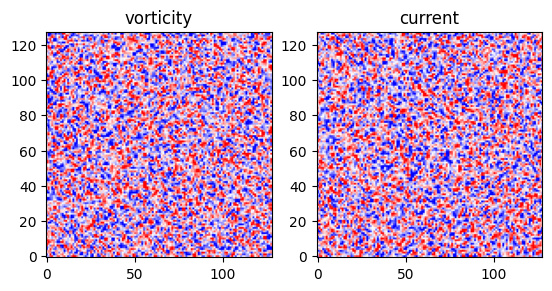

In [1]:
import jax 
import jax.numpy as jnp
import lib.mhd_jax as mhd_jax

#double or single precision
precision = jnp.float64
if (precision == jnp.float64):
    jax.config.update("jax_enable_x64", True)

###############################
# Physical/grid parameters
###############################

n   = 128  # grid resolution
nu  = 1/40 # Fluid dissipation
eta = 1/40 # Magnetic dissipation
b0  = [0.0, 0.1] # Mean magnetic field
u0  = [0.0, 0.0] # Mean flow field

# Construct a dictionary for grid information
param_dict = mhd_jax.construct_domain(n, precision)

# Get grids
x = param_dict['x']
y = param_dict['y']

# Consider Kolmogorov forcing with wavenumber 4
# Specify the forcing as a string, since it is much cheaper to store a string
# than a fully gridded forcing
param_dict['forcing_str'] = "lambda x,y : -4*jnp.cos(4*y)"
forcing_fn = eval(param_dict['forcing_str'])
forcing = forcing_fn(x,y) 

# Add physical parameters to the param_dict for easy use
param_dict.update( {'nu': nu, 'eta': eta, 'b0': b0, 'forcing': forcing} )

# Generate random initial data. 
# f contains the vorticity and current fields
# f[0,:,:] - vorticity
# f[1,:,:] - current
key = jax.random.PRNGKey(seed=321)
f = 10*jax.random.normal( key, shape=[2,n,n] )

# f contains unphysical modes with the random initialization.
# we can fix this by dealiasing with a mask
f = param_dict['mask'] * jnp.fft.rfft2(f)
f = jnp.fft.irfft2(f)

# mhd_jax comes with a visualization function
figure, axis = mhd_jax.vis(f, in_spectral=False)

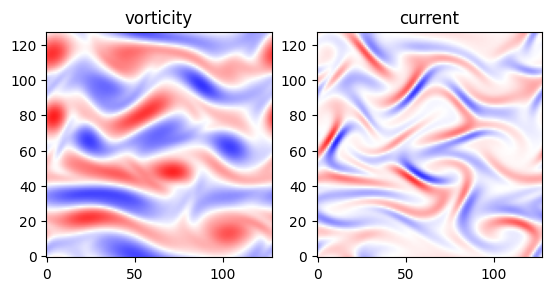

In [2]:
# Let's do some time evolution! Evolve a transient.

import lib.timestepping as timestepping

#Integrate a transient
dt = 1/256 #timestep
transient_steps = 12*1024

#evolve in Fourier space
f = jnp.fft.rfft2(f)

#Shoot forward
v_fn = lambda f : mhd_jax.state_vel(f, param_dict, include_dissipation=True)
f = timestepping.rk4(f, dt*transient_steps, transient_steps, v_fn)

# mhd_jax comes with a visualization function
figure, axis = mhd_jax.vis(f, in_spectral=True)

In [9]:
#Now that we have a sensible initial condition, we should integrate a bit to make a timeseries.

dt = 1/256
steps = 128 #save this many steps for a recurrence diagram
ministeps = 32 #take this many steps between saving

#Define a lambda for integrating between snapshots
#These take "ministeps" steps. I apologize for my naming scheme.
one_step = jax.jit( lambda f: timestepping.rk4(f, dt*ministeps, ministeps, v_fn) )

#Allocate memory for the trajectory
fs = jnp.zeros([steps,2,n,n//2+1], dtype=f.dtype )

import time
start = time.time()
#I am learning that jax.lax.scan is a better way to gather forward time integration
def wrapper(f, _):
    f_new = one_step(f)
    return f_new, f_new #return carry and what to store
_, fs = jax.lax.scan(  wrapper, f, None, length=steps)
stop = time.time()
print(f"Generating {steps} steps of turbulence took {stop-start} seconds.")

start = time.time()
dist = jnp.zeros([steps, steps])
for i in range(steps):
    diff = jnp.abs(fs) - jnp.abs(fs[i,:,:,:])    
    diff = jnp.reshape( diff, [steps, -1] ) #shape [steps, 2*n*n]
    dist = dist.at[:,i].set( jnp.linalg.vector_norm(diff, axis=1) )
stop = time.time()
print(f"Recurrence diagram computed in {stop - start} seconds")

#normalize distances
dist = dist / jnp.mean(jnp.abs(dist))

Generating 128 steps of turbulence took 0.46768784523010254 seconds.
Recurrence diagram computed in 19.199405670166016 seconds


Note: you may need to restart the kernel to use updated packages.


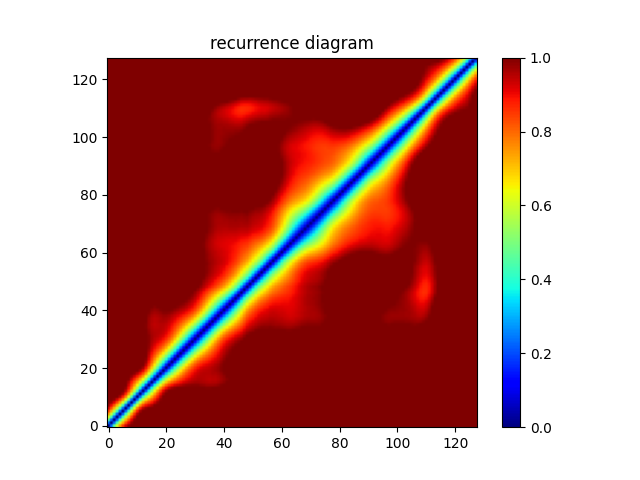

In [10]:
#Visualize this recurrence diagram
%pip install ipympl
%matplotlib widget
import matplotlib.pyplot as plt
plt.figure()
im = plt.imshow(dist, origin='lower', cmap='jet', vmin=0, vmax=1)
plt.colorbar( im )
plt.title("recurrence diagram")
plt.show()

In [ ]:
#Now we can make a guess at a recurrence. Notice the bright streak in the bottom left.
#mousing over, we see that there is a minimum at about 48 and 109. We can automatically make a 
#guess at an RPO with utils.create_state_from_turb(). This function also 

idx = [48, 109]

import lib.utils as utils

#Append timestepping information as well
param_dict.update( {'dt': dt, 'ministeps': ministeps, 'steps': steps} )
turb_dict = {'fs': fs}
input_dict, param_dict = utils.create_state_from_turb(turb_dict, idx, param_dict)

Best symmetry found is (0.39269908169872414, 6, True)


In [ ]:
#For fixed timestep solvers, we need to define parameters for checkpointing.
ministeps = 32
assert( param_dict['steps'] % ministeps == 0 )
param_dict.update({"ministeps": ministeps, "num_checkpoints": param_dict['steps']//ministeps })

print(f"using {param_dict['steps']} timesteps of type {type(param_dict['steps'])} ")



###############################
# Begin Adjoint Descent
###############################

import lib.adam as adam
import lib.loss_functions as loss_functions
import lib.dictionaryIO as dictionaryIO

import os
os.makedirs( "temp_data/adjoint_descent", exist_ok=True)

maxit = 1024
lr = 1e-2
mode = "RK4"
save_every = 32

#initialize ADAM variables and JIT the ADAM step.
m, v = adam.init_adam(input_dict)
update_fn = jax.jit(adam.adam_update)


#Define a function to compute the vlaue of the loss and the gradient simultaneously
loss_fn = lambda input_dict: loss_functions.loss_RPO( input_dict, param_dict, mode )
grad_fn = jax.jit(jax.value_and_grad(loss_fn, has_aux=True))

for t in range(maxit):
    #Compute the loss function and gradient
    start = time.time()
    (loss, info), grad = grad_fn(input_dict)
    stop = time.time()
    walltime = stop-start

    #Complain if the adaptive timestepping fails to complete integration.
    if isinstance(info, dict) and info.get("completed") is False:
        print("ERROR: did not complete integration...")
        print("Integration info for debugging:")
        print(info)
        exit()
    
    #Apply the ADAM update
    input_dict, m, v = update_fn(input_dict, grad, m, v, t+1, lr=lr, beta1=0.9, beta2=0.999, eps=1e-6)

    #dealias fields
    f = input_dict['fields']
    f = jnp.fft.rfft2(f) * param_dict['mask']
    f = jnp.fft.irfft2(f)
    input_dict['fields'] = f

    #Print diagnostics
    #print(f"{t}: loss={loss:.6f}, walltime={walltime:.3f}, T={input_dict['T']:.3f}, sx={input_dict['sx']:.3f}, completed={info['completed']}, fevals={info['fevals']}, accepted={info['accepted']}, rejected={info['rejected']}")
    print(f"{t}: loss={loss:.6f}, walltime={walltime:.3f}, T={input_dict['T']:.3f}, sx={input_dict['sx']:.3f}")

    #Save the state every so often
    if ( t % save_every == 0 ):
        remove_bloat = lambda param_dict : dictionaryIO.remove_grid_information(param_dict)
        dictionaryIO.save_dicts( f"temp_data/adjoint_descent/{t}.npz", input_dict, remove_bloat(param_dict) )


using 1952 timesteps of type <class 'int'> 
0: loss=4.401262, walltime=3.097, T=7.645, sx=0.373
1: loss=4.100667, walltime=0.000, T=7.655, sx=0.363
2: loss=3.876053, walltime=0.000, T=7.665, sx=0.353
3: loss=3.733744, walltime=0.000, T=7.675, sx=0.343
4: loss=3.628883, walltime=0.000, T=7.684, sx=0.335
5: loss=3.549340, walltime=0.000, T=7.693, sx=0.327
6: loss=3.488224, walltime=0.000, T=7.701, sx=0.322
7: loss=3.423404, walltime=0.000, T=7.707, sx=0.319
8: loss=3.356982, walltime=0.000, T=7.713, sx=0.316
9: loss=3.301421, walltime=0.000, T=7.718, sx=0.314
10: loss=3.255547, walltime=0.000, T=7.722, sx=0.311
11: loss=3.203953, walltime=0.000, T=7.725, sx=0.308
12: loss=3.141862, walltime=0.000, T=7.729, sx=0.304
13: loss=3.078648, walltime=0.000, T=7.732, sx=0.301
14: loss=3.022346, walltime=0.000, T=7.737, sx=0.298
15: loss=2.970158, walltime=0.001, T=7.742, sx=0.297
16: loss=2.915895, walltime=0.000, T=7.748, sx=0.298
17: loss=2.863310, walltime=0.001, T=7.755, sx=0.299
18: loss=2.8